# Exploration 01 — exploratory data analysis of every QM9 field

> **Exploratory** (CLAUDE.md, "Exploration"). This notebook chooses no model setting itself; its findings become
> the cleaning, feature-engineering and scaling decisions in notebooks 02 and 03.
> **Data:** the training pool P only (7,131 molecules). No test molecule and no unseen-formula molecule is read, and
> the full QM9 table is not used either, because it contains the unseen formulas.

**Part 1 of the classical analysis.** Every later notebook builds on this one:

| Notebook | Step | Uses from earlier steps |
|---|---|---|
| **01 (this)** | exploratory data analysis of every field | — |
| 02 | data cleaning and feature engineering | the integrity, duplicate and redundancy findings |
| 03 | standardization / normalization and effective dimension | the distribution shapes and tails |
| 04 | models and their effective number of parameters | the cleaned features and the chosen scaling |
| 05 | generalization to new formulas, error analysis | everything above |

QM9 provides, per molecule, atomic numbers Z and 3D coordinates R (the brief's inputs), the target |μ|, and much
more from the same DFT calculation: Mulliken charges, 14 other properties, vibrational frequencies, and SMILES and
InChI strings. **This EDA examines all of them**, to learn which carry information about |μ|, which are redundant
or broken, and which a headline model may use at all.

In [1]:
# Environment check: stops here, with setup instructions, unless this kernel is the project
# environment (README.md, "Setup"). Version differences from requirements.txt only warn.
try:
    from qm9dipole.provenance import check_environment
except ModuleNotFoundError as e:
    raise RuntimeError(
        "The qm9dipole package is not installed in this kernel's environment. Follow "
        "README.md (Setup), then select that environment as the notebook kernel."
    ) from e

print(check_environment())

environment OK: Python 3.12.14, 16 pinned packages checked, 0 differ; package and notebook are in the same checkout


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display

from qm9dipole import REPO_ROOT
from qm9dipole.data import load_qm9_table
from qm9dipole.eda import FROM_ZR, DFT, SCALAR_PROPERTIES, data_dictionary, integrity_checks, per_molecule_summaries
from qm9dipole.plots import (AXIS, DIVERGING, INK_SECONDARY, MUTED, ROLE_COLORS, ROLE_LABELS, SEQUENTIAL,
                             SERIES, SURFACE, use_style)
from qm9dipole.provenance import save_result
from qm9dipole.splits import load_splits, training_pool

use_style()
FIG_DIR = REPO_ROOT / "figures"
CFG = yaml.safe_load((REPO_ROOT / "configs" / "explore.yaml").read_text())

table = load_qm9_table()
splits = load_splits()
P = table.set_index("id").loc[training_pool(splits, table)].reset_index()
# Guard: nothing from either test set, and no unseen formula, enters this notebook.
assert not set(P["id"]) & (set(splits.test_familiar) | set(splits.test_unseen))
assert not set(P["formula"]) & set(splits.unseen_formulas)
y = P.set_index("id")["mu"]
formula = P.set_index("id")["formula"]
print(f"parsed table: {table.shape[0]:,} molecules × {table.shape[1]} columns")
print(f"training pool P: {len(P):,} molecules, {formula.nunique()} formulas (no test molecule, no unseen formula)")

parsed table: 133,885 molecules × 27 columns
training pool P: 7,131 molecules, 523 formulas (no test molecule, no unseen formula)


## 1. Shape, columns and roles

Every column of the parsed table, with its unit and **role**. The role matters as much as the content:
- **headline input / function of Z and R:** usable by headline models. The brief's pipeline is composition +
  geometry → model → |μ|;
- **DFT output:** computed in the same B3LYP calculation that produced |μ|. A model fed these answers "given the
  electron density, what is |μ|?", a different question from the brief's, so they are exploration-only (CLAUDE.md
  rule 1);
- **identifier:** names and bookkeeping, not inputs.

The rotational constants A, B and C are listed as functions of Z and R. Section 2 verifies this numerically.

In [3]:
dd = data_dictionary()
dd["dtype"] = dd["column"].map(lambda c: type(P[c].iloc[0]).__name__ if P[c].dtype == object else str(P[c].dtype))
display(dd.style.hide(axis="index"))
print(dd["role"].value_counts().to_string())

column,per,unit,meaning,role,dtype
id,molecule,,QM9 index (GDB-17 numbering),identifier / bookkeeping,int64
formula,molecule,,"element counts, e.g. C2H6O (from Z)",function of Z and R (headline-legal),str
n_atoms,molecule,,number of atoms (from Z),function of Z and R (headline-legal),int64
n_heavy,molecule,,"number of C, N, O, F atoms (from Z)",function of Z and R (headline-legal),int64
Z,atom,,atomic number,headline input,ndarray
R,atom,Å,Cartesian coordinates of the B3LYP-optimized geometry,headline input,ndarray
q,atom,e,Mulliken partial charge,DFT output (exploration only),ndarray
A,molecule,GHz,rotational constant (largest),function of Z and R (headline-legal),float64
B,molecule,GHz,rotational constant,function of Z and R (headline-legal),float64
C,molecule,GHz,rotational constant (smallest),function of Z and R (headline-legal),float64


role
DFT output (exploration only)           13
function of Z and R (headline-legal)     6
identifier / bookkeeping                 5
headline input                           2
target                                   1


## 2. Data types, missing values and integrity

Missing values, internal consistency and physical sanity, checked on every pool molecule. The integrity rules come
from the QM9 readme and from physics: a neutral molecule's charges sum to zero; a stable geometry has no imaginary
vibrational frequency; enthalpy exceeds internal energy by RT; rotational constants follow from the masses and
coordinates.

In [4]:
checks = integrity_checks(P)
display(checks.style.format({"max deviation": "{:.2g}"}, na_rep="").hide(axis="index"))

summaries = per_molecule_summaries(P)
doubled = summaries["n_freqs_listed"] == 2 * summaries["n_freqs_expected"]
print(f"frequency lists printed twice in the raw file: {doubled.sum()} of {len(P):,} pool molecules "
      f"(all others list exactly 3n − 6 modes)")
ex = P.set_index("id").loc[summaries.index[doubled][0]]
f = ex["freqs"]
k = len(f) // 2
print(f"  example: molecule {summaries.index[doubled][0]} ({ex['smiles']}), {ex['n_atoms']} atoms -> {len(f)} values; "
      f"largest difference between the two halves {np.abs(f[:k] - f[k:]).max():.2f} cm⁻¹")

check,checked,violations,max deviation,note
len(Z) = len(R) = len(q) = n_atoms,7131,0,,
no missing scalar values,7131,0,,
neutral: |Σ q| < 1e-4 e,7131,0,5e-06,
μ ≥ 0,7131,0,,
gap = lumo − homo (values are rounded to 1e-4 Ha),7131,0,0.0001,
H − U = RT at 298.15 K (0.000944 Ha),7131,0,1e-06,
U0 < U and G < H,7131,0,,
"A ≥ B ≥ C, or A = 0 (linear)",7131,0,,
"rotational constants = 505.379 GHz·amu·Å² / I(Z, R)",7131,0,1.2e-05,relative; I from isotope masses and R
frequencies: 3n − 6 listed (3n − 5 if linear),7131,25,,exactly twice that is a doubled list in the raw file


frequency lists printed twice in the raw file: 25 of 7,131 pool molecules (all others list exactly 3n − 6 modes)
  example: molecule 29 (CC#CC), 10 atoms -> 48 values; largest difference between the two halves 0.00 cm⁻¹


## 3. Duplicates: InChI vs geometry

Two records of the same molecule would put a validation molecule's twin into its training fold and inflate CV
scores. Two candidate tests:
- **same InChI.** Standard InChI deliberately merges **tautomers** (molecules that differ only in where a hydrogen
  sits, e.g. 4-hydroxypyridine vs 4-pyridone). Those are different molecules with different dipoles, so InChI
  overcounts;
- **same geometry:** same formula and the same Coulomb-matrix spectrum to 0.01. This uses Z and R only.

In [5]:
from qm9dipole.cleaning import duplicate_groups
from qm9dipole.descriptors import cm_spectrum

spectra = np.stack([cm_spectrum(z, r) for z, r in zip(P["Z"], P["R"])])
geo = duplicate_groups(P["id"].to_numpy(), P["formula"], spectra, CFG["cleaning"]["duplicate_cm_decimals"])
geo_mu_range = y.loc[geo.index].groupby(geo).agg(lambda v: v.max() - v.min())

by_inchi = P[P["inchi"].duplicated(keep=False)].groupby("inchi")["id"].apply(list)
inchi_rows = []
for ids in by_inchi:
    same_geometry = len(set(geo.reindex(ids).dropna())) == 1 and geo.reindex(ids).notna().all()
    inchi_rows.append({"ids": ids, "same geometry": same_geometry, "|μ| range (D)": np.ptp(y.loc[ids]),
                       "SMILES": " | ".join(P.set_index("id").loc[ids, "smiles"])})
inchi_groups = pd.DataFrame(inchi_rows)

# Leakage needs both twins in the same training set (one in a training fold, one in a validation fold).
twins_together = {(s, n): int((geo.reindex(ids).dropna().value_counts() >= 2).sum())
                  for s, by_n in splits.train.items() for n, ids in by_n.items()}
in_some_set = set(geo.index) & set(np.concatenate([ids for by_n in splits.train.values() for ids in by_n.values()]))
print(f"same InChI: {inchi_groups['ids'].map(len).sum()} pool molecules in {len(inchi_groups)} groups; "
      f"{(~inchi_groups['same geometry']).sum()} groups are different molecules (tautomers), "
      f"|μ| differing by up to {inchi_groups.loc[~inchi_groups['same geometry'], '|μ| range (D)'].max():.1f} D")
print(f"same geometry: {len(geo)} pool molecules in {geo.nunique()} groups; |μ| identical within "
      f"{geo_mu_range.max():.4f} D: true duplicates")
print(f"{len(in_some_set)} of them belong to some training set S_(s,N), but no S_(s,N) holds both twins of a pair "
      f"(pairs together: {max(twins_together.values())} in every one of the {len(twins_together)} sets)")
assert max(twins_together.values()) == 0, "a training set holds both copies of a duplicate"
display(pd.concat([inchi_groups[inchi_groups["same geometry"]].head(3),
                   inchi_groups[~inchi_groups["same geometry"]].sort_values("|μ| range (D)").tail(3)])
        .style.format({"|μ| range (D)": "{:.3f}"}).hide(axis="index"))

same InChI: 357 pool molecules in 171 groups; 159 groups are different molecules (tautomers), |μ| differing by up to 6.3 D
same geometry: 24 pool molecules in 12 groups; |μ| identical within 0.0027 D: true duplicates
8 of them belong to some training set S_(s,N), but no S_(s,N) holds both twins of a pair (pairs together: 0 in every one of the 9 sets)


ids,same geometry,|μ| range (D),SMILES
"[129412, 129579]",True,0.000,[NH2]=C(N)Nc1ncnn1 | [NH2]=C(N)Nc1ncnn1
"[4211, 4215]",True,0.000,Fc1cnccn1 | Fc1nccnc1
"[27046, 49879]",True,0.003,Nc1c(oc(=O)o1)C=O | Nc1oc(=O)oc1C=O
"[23756, 23776]",False,5.350,Oc1ccncc1F | Fc1c[nH]ccc1=O
"[910, 923, 957]",False,6.022,O=c1cc[nH]cn1 | O=c1[nH]cncc1 | Oc1ncncc1
"[20608, 20615]",False,6.302,Cc1c(nn[nH]1)C#N | Cc1c([nH]nn1)C#N


## 4. Summary statistics of every scalar field

The 15 properties of each record's second line, the molecule-level counts, and scalar summaries of the
array-valued fields: composition (from Z), how far the coordinate centroid sits from the origin (from R), charge
statistics (from q) and the frequency range (from freqs). Skewness above ~1 or a large kurtosis flags a long tail.
Section 6 shows these as histograms, and notebook 03 tests whether a transform helps.

In [6]:
mol = P.set_index("id")
scalars = mol[list(SCALAR_PROPERTIES) + ["n_atoms", "n_heavy"]].join(
    summaries[["n_C", "n_H", "n_N", "n_O", "n_F", "centroid_offset", "q_max_abs", "freq_min", "freq_max"]])
stats = scalars.describe(percentiles=[0.01, 0.5, 0.99]).T
stats["skew"], stats["kurtosis"], stats["distinct"] = scalars.skew(), scalars.kurt(), scalars.nunique()
role = dict(zip(dd["column"], dd["role"]))
stats.insert(0, "role", [role.get(c, FROM_ZR if c.startswith("n_") or c == "centroid_offset" else DFT)
                         for c in stats.index])
display(stats.drop(columns="count").style.format(precision=3, thousands=","))

,role,mean,std,min,1%,50%,99%,max,skew,kurtosis,distinct
A,function of Z and R (headline-legal),124.704,"7,840.081",0.000,1.835,3.788,20.015,"619,867.683",72.956,"5,586.389","7,079"
B,function of Z and R (headline-legal),1.819,6.603,0.344,0.546,1.488,4.800,437.904,54.459,"3,246.778","7,001"
C,function of Z and R (headline-legal),1.399,4.548,0.338,0.521,1.127,3.921,282.945,49.472,"2,684.751","6,943"
mu,target,2.827,1.763,0.000,0.011,2.647,7.553,29.556,1.729,13.076,"6,628"
alpha,DFT output (exploration only),66.623,12.791,6.310,38.227,66.220,97.201,196.620,0.264,2.118,"3,729"
homo,DFT output (exploration only),-0.250,0.029,-0.396,-0.326,-0.249,-0.181,-0.104,-0.173,1.010,"1,358"
lumo,DFT output (exploration only),-0.005,0.057,-0.175,-0.129,-0.007,0.093,0.117,-0.099,-0.774,"2,103"
gap,DFT output (exploration only),0.245,0.056,0.025,0.145,0.236,0.378,0.505,0.397,-0.299,"2,155"
r2,DFT output (exploration only),"1,058.552",347.763,19.000,374.888,"1,040.109","2,110.306","3,374.753",0.831,2.251,"7,124"
zpve,DFT output (exploration only),0.119,0.045,0.016,0.045,0.112,0.249,0.274,0.758,0.263,"6,922"


## 5. The target: |μ|

|μ| measures how far the molecule's centres of positive and negative charge are pulled apart (1 D ≈ 0.21 e·Å). It
is non-negative, right-skewed, has a spike near zero from symmetric molecules, and a long tail. The panels compare
the raw scale with two variance-stabilizing transforms. A model fit on a transformed target still predicts debye
after inverting, and notebook 03 tests by CV whether that helps.

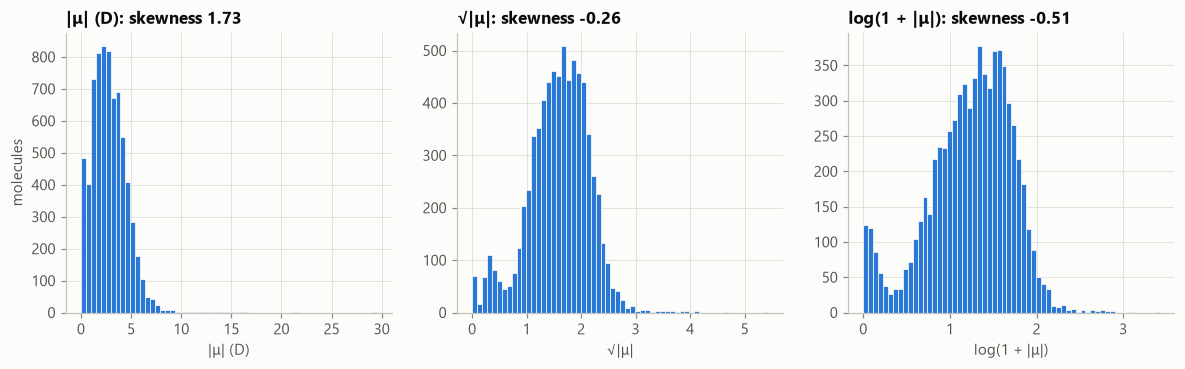

7,131 molecules: mean 2.83 D, median 2.65 D, std 1.76 D
exactly 0 D: 26; below 0.25 D: 384 (5.4%); ≥ 9 D: 32; largest 29.6 D


,MAE (D),RMSE (D)
always predict the mean,1.343,1.763
always predict the median,1.336,1.772


,smiles,|μ| (D),max |Mulliken q| (e)
id,,,
123126,[NH3]CCCCCC(=O)[O],29.56,0.48
100457,[NH3]C[C@@H](O)C#CC(=O)[O],21.51,0.46
99225,CNC(=[NH2])OCC(=O)[O],16.74,0.61
96679,CNC(=[NH2])OCC(=O)[O],16.74,0.61
129340,[NH2]=CNCc1nnnn1,15.86,0.49
55479,[O]C(=O)[C@H]1C[NH2]CCO1,15.66,0.49


In [7]:
transforms = {"|μ| (D)": y, "√|μ|": np.sqrt(y), "log(1 + |μ|)": np.log1p(y)}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
for ax, (name, v) in zip(axes, transforms.items()):
    ax.hist(v, bins=60, color=SERIES[0], edgecolor=SURFACE, linewidth=0.5)
    ax.set(xlabel=name, title=f"{name}: skewness {v.skew():.2f}")
axes[0].set_ylabel("molecules")
fig.savefig(FIG_DIR / "explore01_target.png")
plt.show()

print(f"{len(y):,} molecules: mean {y.mean():.2f} D, median {y.median():.2f} D, std {y.std():.2f} D")
print(f"exactly 0 D: {(y == 0).sum()}; below 0.25 D: {(y < 0.25).sum()} ({(y < 0.25).mean():.1%}); "
      f"≥ 9 D: {(y >= 9).sum()}; largest {y.max():.1f} D")
constant = pd.DataFrame({"MAE (D)": [(y - y.mean()).abs().mean(), (y - y.median()).abs().mean()],
                         "RMSE (D)": [np.sqrt(((y - y.mean()) ** 2).mean()), np.sqrt(((y - y.median()) ** 2).mean())]},
                        index=["always predict the mean", "always predict the median"])
display(constant.style.format("{:.3f}"))
top = mol.loc[y.sort_values().index[-6:], ["smiles", "mu"]].join(summaries["q_max_abs"])
display(top.rename(columns={"mu": "|μ| (D)", "q_max_abs": "max |Mulliken q| (e)"}).iloc[::-1].style.format(precision=2))

## 6. Every scalar field, one at a time

Each panel shows the 0.5–99.5 percentile range so the bulk is visible; the title gives the skewness, and the corner
note gives the full range when the tails reach beyond the plot. Blue: functions of Z and R. Orange: DFT outputs
(exploration only).

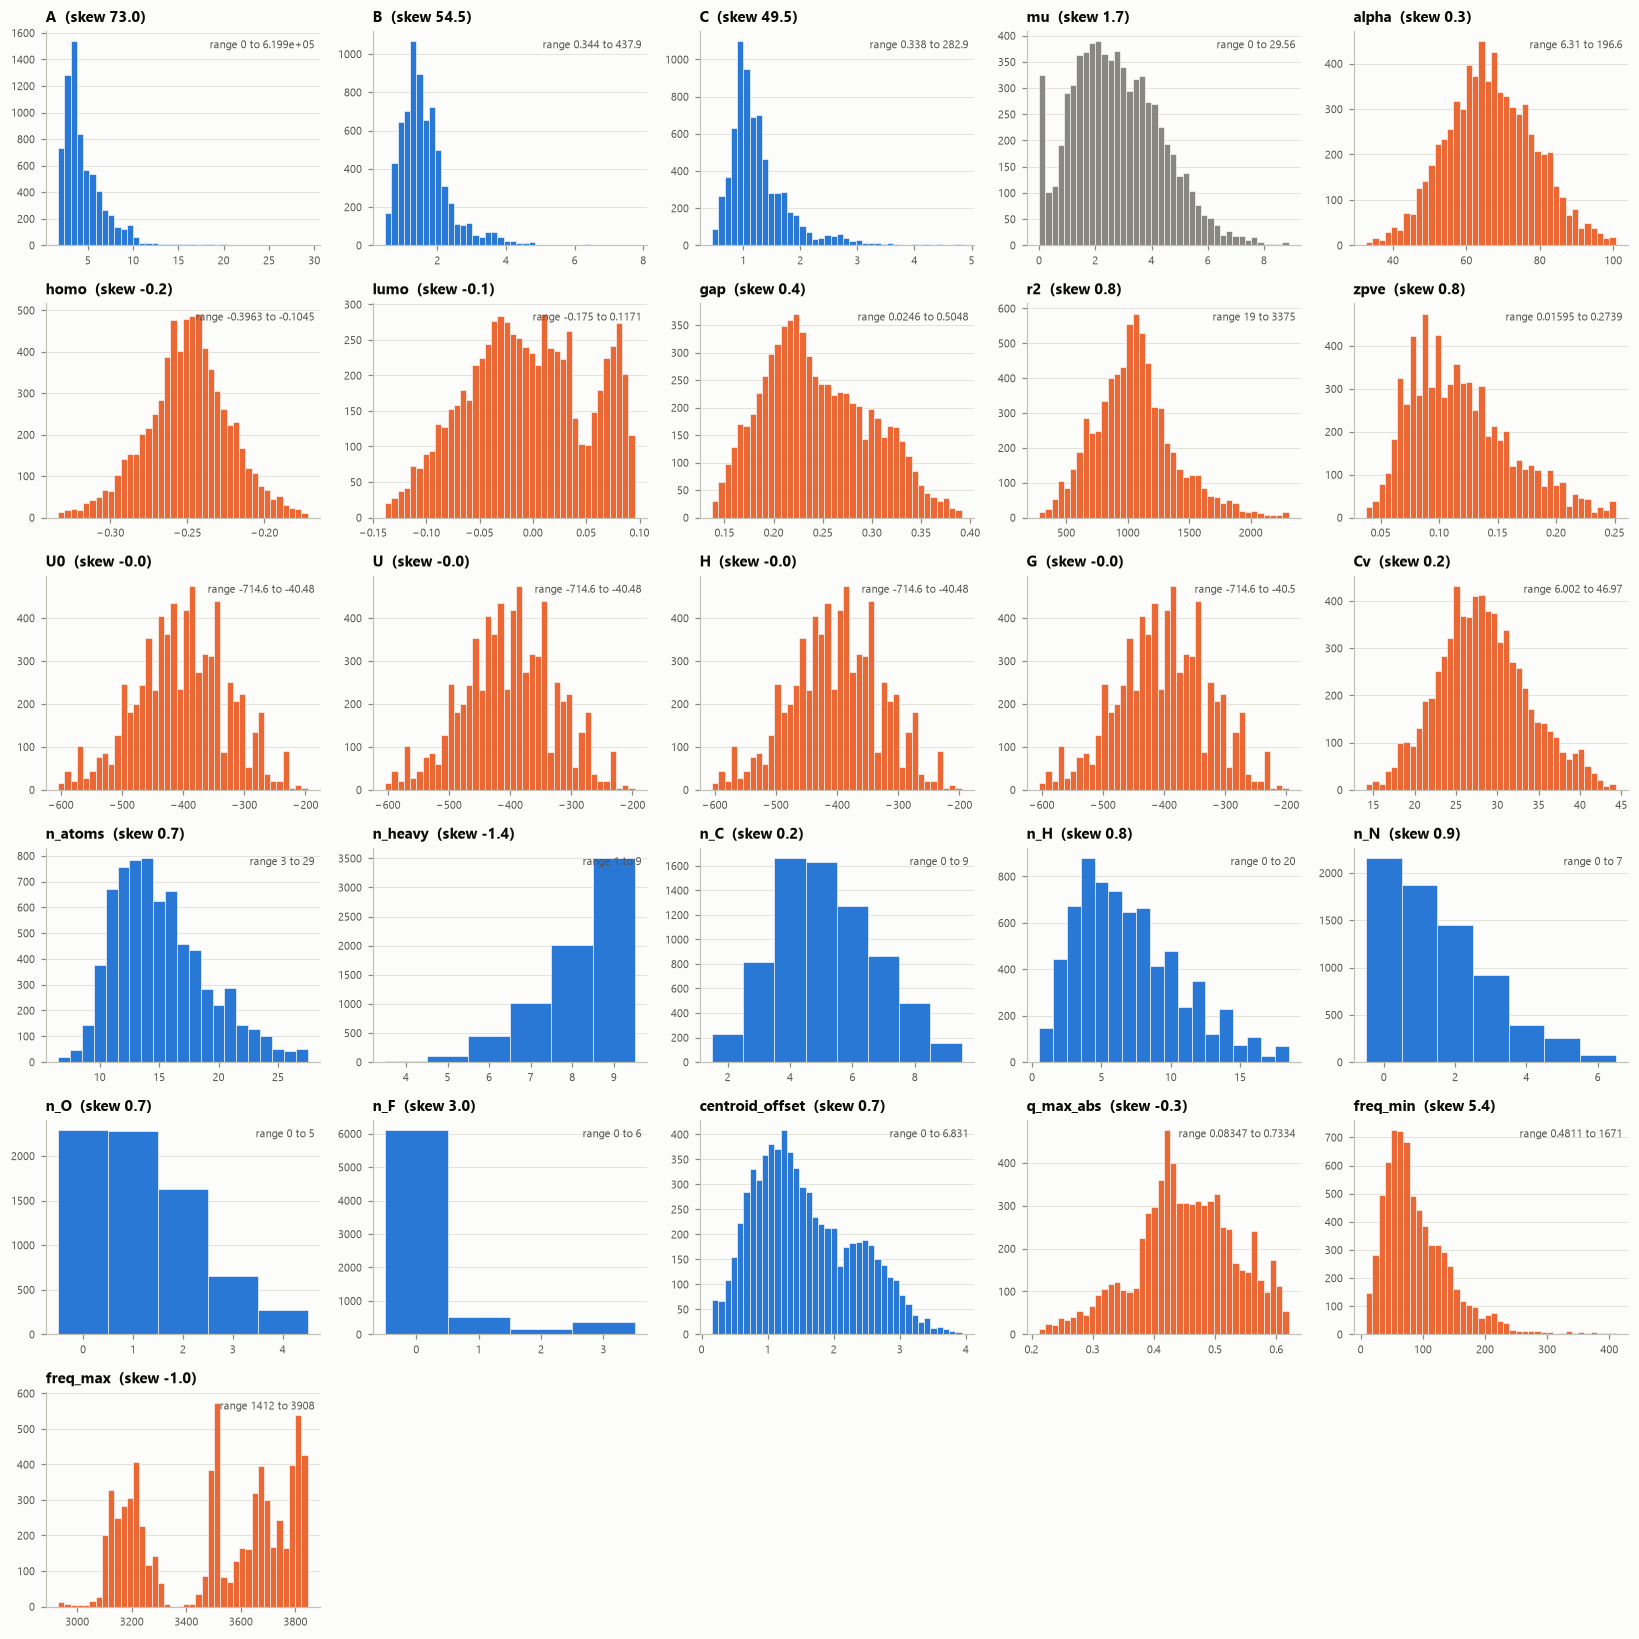

In [8]:
cols = list(stats.index)
n_cols = 5
fig, axes = plt.subplots(int(np.ceil(len(cols) / n_cols)), n_cols, figsize=(15, 2.5 * np.ceil(len(cols) / n_cols)))
for ax, c in zip(axes.flat, cols):
    v = scalars[c]
    lo, hi = v.quantile([0.005, 0.995])
    inside = v[(v >= lo) & (v <= hi)]
    color = ROLE_COLORS["dft"] if stats.loc[c, "role"] == DFT else (MUTED if c == "mu" else ROLE_COLORS["legal"])
    bins = np.arange(lo - 0.5, hi + 1.5) if v.nunique() <= 30 and (v == v.round()).all() else 40
    ax.hist(inside, bins=bins, color=color, edgecolor=SURFACE, linewidth=0.4)
    ax.set_title(f"{c}  (skew {v.skew():.1f})", fontsize=9.5)
    ax.tick_params(labelsize=7.5)
    ax.grid(axis="x", visible=False)
    if v.max() > hi or v.min() < lo:
        ax.text(0.98, 0.92, f"range {v.min():.4g} to {v.max():.4g}", transform=ax.transAxes, ha="right",
                fontsize=7, color=INK_SECONDARY)
for ax in list(axes.flat)[len(cols):]:
    ax.axis("off")
fig.tight_layout()
fig.savefig(FIG_DIR / "explore01_scalar_distributions.png")
plt.show()

## 7. The per-atom fields: Z, R, q and the frequencies

### 7a. Coordinates R: what do raw coordinates encode?
If QM9 stored every molecule centred and aligned in a standard frame, raw coordinates could carry chemistry
directly. If not, they carry an arbitrary placement, and a model must use invariant descriptors (M2's finding,
from the other direction).

In [9]:
from qm9dipole.features import ISOTOPE_MASS

def frame_alignment(z, r):
    """Largest off-diagonal of the inertia tensor in the stored frame, relative to its trace (0 if aligned)."""
    m = np.array([ISOTOPE_MASS[int(a)] for a in z])
    X = r - (m[:, None] * r).sum(0) / m.sum()
    second = np.einsum("i,ij,ik->jk", m, X, X)
    tensor = np.trace(second) * np.eye(3) - second
    return np.abs(tensor - np.diag(np.diag(tensor))).max() / np.trace(tensor)

alignment = np.array([frame_alignment(z, r) for z, r in zip(P["Z"], P["R"])])
print(f"centroid distance from the origin: median {summaries['centroid_offset'].median():.2f} Å, "
      f"max {summaries['centroid_offset'].max():.2f} Å")
print(f"stored frame aligned with the principal axes (off-diagonal < 1% of trace): {(alignment < 0.01).mean():.1%}")

centroid distance from the origin: median 1.41 Å, max 6.83 Å
stored frame aligned with the principal axes (off-diagonal < 1% of trace): 6.9%


### 7b. Bond lengths: bonds and bond orders hidden in R

Bonds are inferred from distances (d < 1.15 × sum of covalent radii; DECISIONS.md). Within one element pair, bond
length tracks bond order: triple < double < single. Empty valleys between the peaks would let bond orders be
counted from geometry alone. Carbonyl C=O and nitrile C≡N are among the most polar groups in organic chemistry.

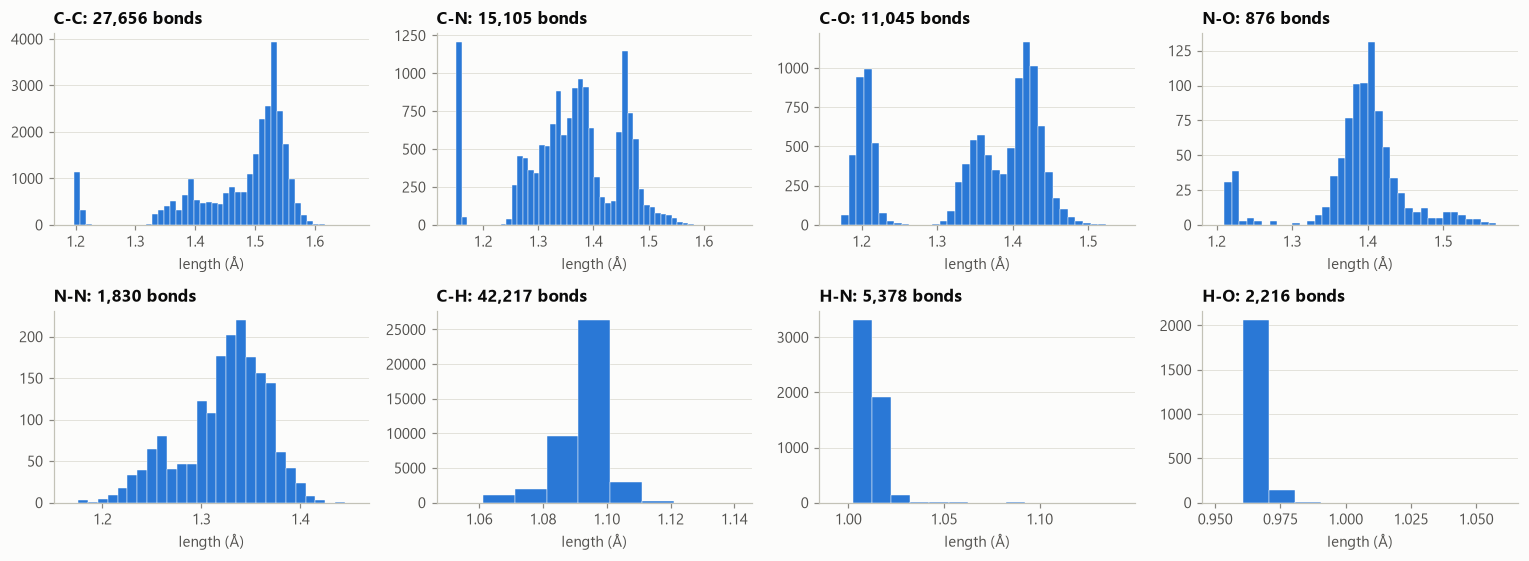

In [10]:
from qm9dipole.eda import bond_lengths

lengths = bond_lengths(P)
pairs = ["C-C", "C-N", "C-O", "N-O", "N-N", "C-H", "H-N", "H-O"]
fig, axes = plt.subplots(2, 4, figsize=(14, 5.2))
for ax, pair in zip(axes.flat, pairs):
    v = lengths.loc[lengths["pair"] == pair, "length"]
    ax.hist(v, bins=np.arange(v.min() - 0.01, v.max() + 0.02, 0.01), color=ROLE_COLORS["legal"], edgecolor=SURFACE,
            linewidth=0.3)
    ax.set(title=f"{pair}: {len(v):,} bonds", xlabel="length (Å)")
    ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "explore01_bond_lengths.png")
plt.show()

### 7c. Mulliken charges q (DFT output, exploration only)

Per-atom partial charges from the DFT electron density. If μ were exactly a sum of point charges, |Σ qᵢ rᵢ| would
equal it. It doesn't, because charges are an approximation and the electron cloud is not point-like, but how close
it gets bounds what a model that "knew the charges" could do.

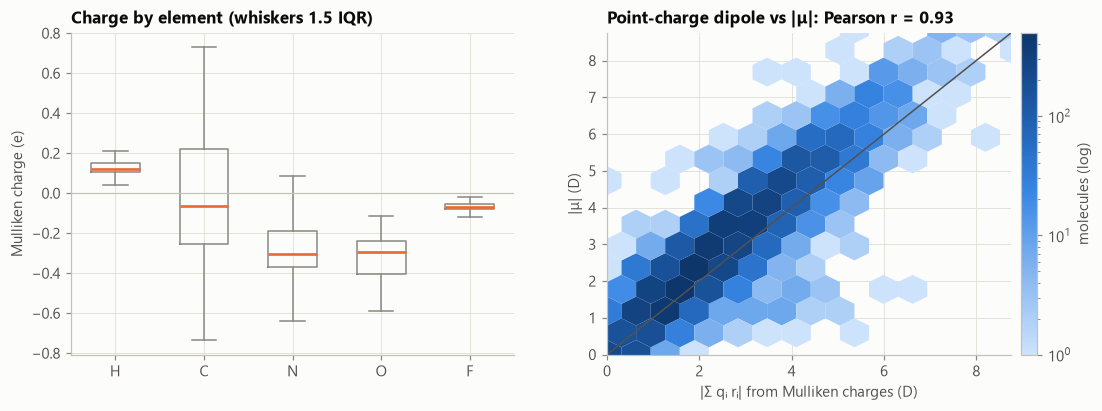

In [11]:
from qm9dipole.features import charge_features

element = {1: "H", 6: "C", 7: "N", 8: "O", 9: "F"}
per_atom = pd.DataFrame({"element": [element[int(a)] for z in P["Z"] for a in z],
                         "q": np.concatenate(P["q"].to_numpy())})
charge = pd.DataFrame([charge_features(q, r) for q, r in zip(P["q"], P["R"])], index=mol.index,
                      columns=["charge_dipole_D", "max_abs_charge", "charge_separation"])

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1, 1.1]})
order = ["H", "C", "N", "O", "F"]
style = dict(color=MUTED, linewidth=1)
ax0.boxplot([per_atom.loc[per_atom["element"] == e, "q"] for e in order], tick_labels=order, showfliers=False,
            widths=0.55, medianprops=dict(color=ROLE_COLORS["dft"], linewidth=1.75), boxprops=style,
            whiskerprops=style, capprops=style)
ax0.axhline(0, color=AXIS, linewidth=0.8)
ax0.set(ylabel="Mulliken charge (e)", title="Charge by element (whiskers 1.5 IQR)")
hb = ax1.hexbin(charge["charge_dipole_D"], y, gridsize=45, bins="log", cmap=SEQUENTIAL, mincnt=1, linewidths=0)
r = np.corrcoef(charge["charge_dipole_D"], y)[0, 1]
lim = float(np.percentile(np.r_[charge["charge_dipole_D"], y], 99.5))
ax1.plot([0, lim], [0, lim], color=INK_SECONDARY, linewidth=1)
ax1.set(xlim=(0, lim), ylim=(0, lim), xlabel="|Σ qᵢ rᵢ| from Mulliken charges (D)", ylabel="|μ| (D)",
        title=f"Point-charge dipole vs |μ|: Pearson r = {r:.2f}")
fig.colorbar(hb, ax=ax1, label="molecules (log)", pad=0.02)
fig.savefig(FIG_DIR / "explore01_charges.png")
plt.show()

### 7d. Vibrational frequencies (DFT output, exploration only)

Each molecule has 3n − 6 harmonic modes. Their distribution has a fingerprint region (below ~1,800 cm⁻¹), X–H
stretches (2,800–3,800 cm⁻¹) and soft torsions near 0. Doubled lists are counted once here.

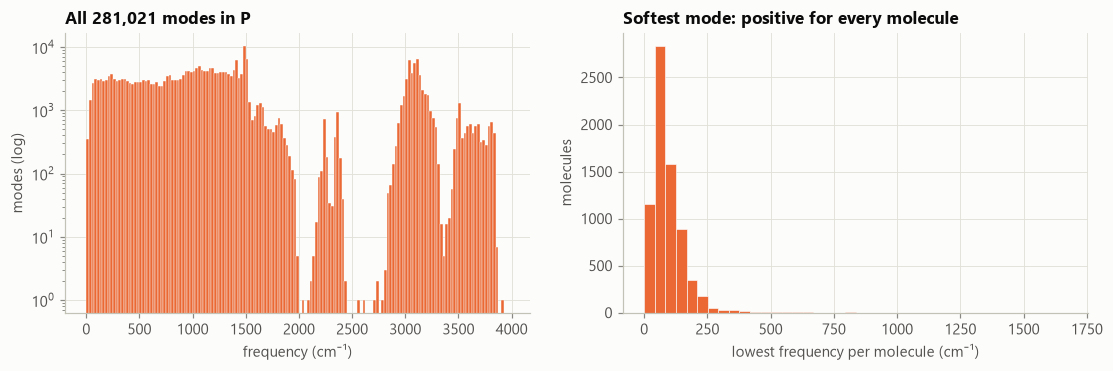

In [12]:
from qm9dipole.cleaning import clean_frequencies

clean = [clean_frequencies(f, n) for f, n in zip(P["freqs"], P["n_atoms"])]
all_modes = np.concatenate(clean)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 3.3))
ax0.hist(all_modes, bins=np.arange(0, 4000, 25), color=ROLE_COLORS["dft"], edgecolor=SURFACE, linewidth=0.3)
ax0.set(yscale="log", xlabel="frequency (cm⁻¹)", ylabel="modes (log)", title=f"All {len(all_modes):,} modes in P")
ax1.hist([f.min() for f in clean], bins=40, color=ROLE_COLORS["dft"], edgecolor=SURFACE, linewidth=0.4)
ax1.set(xlabel="lowest frequency per molecule (cm⁻¹)", ylabel="molecules", title="Softest mode: positive for every molecule")
fig.savefig(FIG_DIR / "explore01_frequencies.png")
plt.show()

## 8. Which fields carry information about |μ|?

Three measures for every scalar field, all computed on the pool:
- **Pearson r:** linear association;
- **Spearman ρ:** monotone association, robust to tails;
- **mutual information (MI, nats):** any dependence, including non-monotone (k-nearest-neighbour estimator). 0
  means independent.

These describe single fields one at a time; a field useless alone can still help in combination. Exploration-only
fields (orange) are shown for understanding, and can only enter clearly labeled exploratory models.

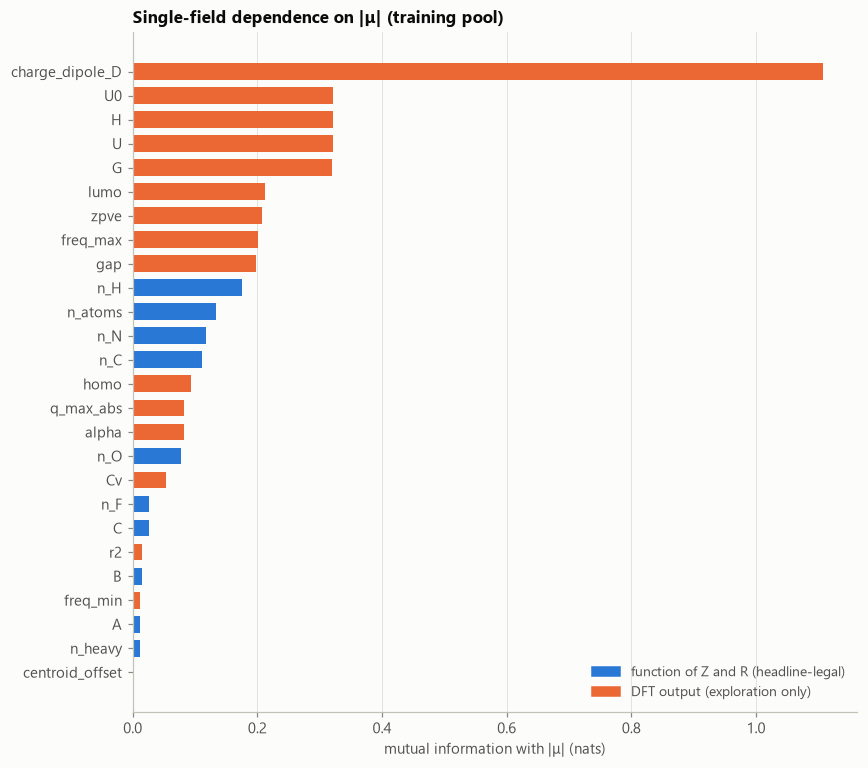

,role,Pearson r,Spearman ρ,MI (nats)
charge_dipole_D,dft,+0.93,+0.92,1.107
U0,dft,-0.21,-0.23,0.321
H,dft,-0.21,-0.23,0.321
U,dft,-0.21,-0.23,0.321
G,dft,-0.21,-0.23,0.320
lumo,dft,-0.32,-0.35,0.213
zpve,dft,-0.29,-0.29,0.208
freq_max,dft,+0.18,+0.15,0.201
gap,dft,-0.33,-0.29,0.198
n_H,legal,-0.31,-0.32,0.175


In [13]:
from matplotlib.patches import Patch
from sklearn.feature_selection import mutual_info_regression

candidates = scalars.drop(columns="mu").join(charge[["charge_dipole_D"]])
candidates = candidates.loc[:, candidates.nunique() > 1]
mi = mutual_info_regression(candidates.to_numpy(), y.to_numpy(), random_state=0)
assoc = pd.DataFrame({
    "role": ["dft" if (stats["role"].get(c, DFT) == DFT) else "legal" for c in candidates.columns],
    "Pearson r": candidates.corrwith(y), "Spearman ρ": candidates.corrwith(y, method="spearman"), "MI (nats)": mi,
}, index=candidates.columns).sort_values("MI (nats)", ascending=False)

fig, ax = plt.subplots(figsize=(8.5, 0.27 * len(assoc) + 1))
show = assoc.iloc[::-1]
ax.barh(show.index, show["MI (nats)"], color=[ROLE_COLORS[r] for r in show["role"]], height=0.7)
ax.legend(handles=[Patch(color=ROLE_COLORS[k], label=ROLE_LABELS[k]) for k in ("legal", "dft")], loc="lower right")
ax.set(xlabel="mutual information with |μ| (nats)", title="Single-field dependence on |μ| (training pool)")
ax.grid(axis="y", visible=False)
fig.savefig(FIG_DIR / "explore01_mutual_information.png")
plt.show()
display(assoc.style.format({"Pearson r": "{:+.2f}", "Spearman ρ": "{:+.2f}", "MI (nats)": "{:.3f}"}))

## 9. Redundancy: how the fields relate to each other

Spearman correlations among all scalar fields, ordered by hierarchical clustering so related fields sit together.
Blue is positive, red negative, gray none. Blocks of near-±1 are redundant: they carry the same information up to a
monotone transform, which notebook 02's cleaning rule removes.

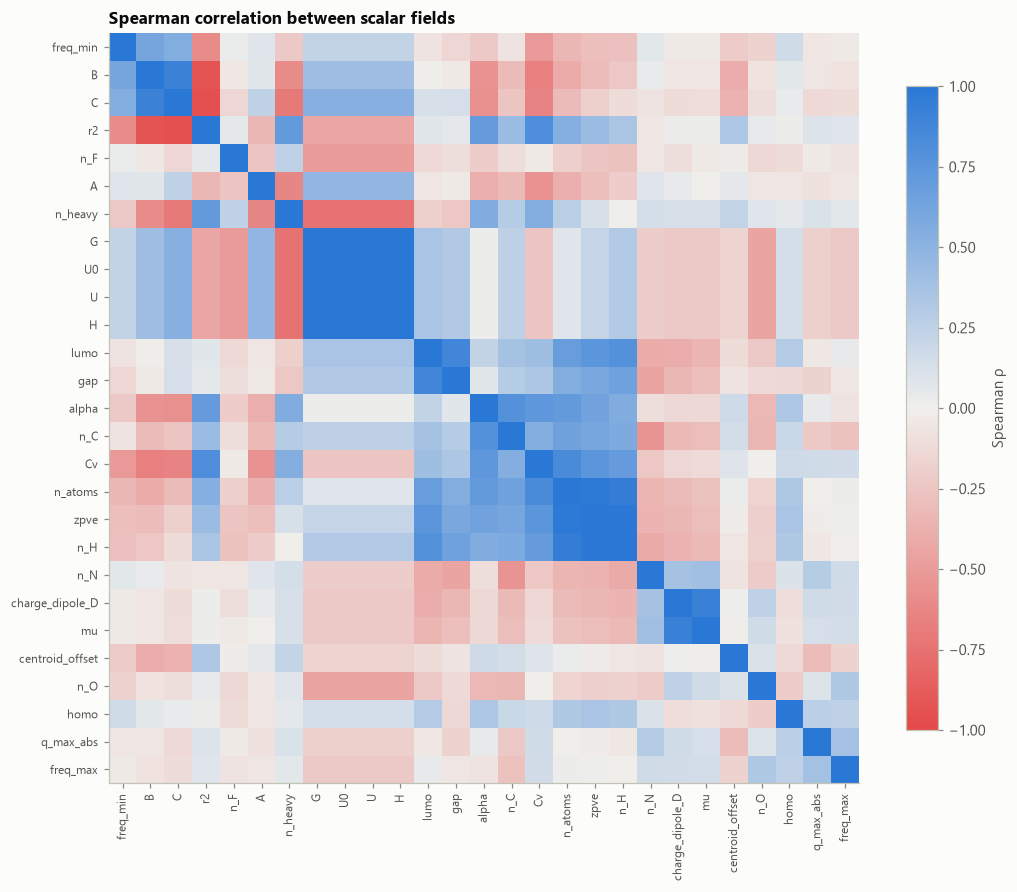

pairs with |ρ| ≥ 0.95 (6 at or above the cleaning threshold 0.99):


In [14]:
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import squareform

corr = candidates.join(y).corr(method="spearman")
dist = squareform(1 - corr.abs().to_numpy(), checks=False)
order = corr.index[leaves_list(linkage(dist, "average"))]
corr = corr.loc[order, order]

fig, ax = plt.subplots(figsize=(11, 9.5))
im = ax.imshow(corr.to_numpy(), cmap=DIVERGING, vmin=-1, vmax=1)
ax.set(xticks=range(len(order)), yticks=range(len(order)), title="Spearman correlation between scalar fields")
ax.set_xticklabels(order, rotation=90, fontsize=8)
ax.set_yticklabels(order, fontsize=8)
ax.grid(False)
fig.colorbar(im, ax=ax, label="Spearman ρ", shrink=0.8)
fig.savefig(FIG_DIR / "explore01_correlations.png")
plt.show()

threshold = CFG["cleaning"]["redundancy_spearman"]
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
near = upper[upper.abs() >= 0.95].sort_values(key=np.abs, ascending=False)
print(f"pairs with |ρ| ≥ 0.95 ({(near.abs() >= threshold).sum()} at or above the cleaning threshold {threshold}):")
display(near.rename("Spearman ρ").to_frame().style.format("{:+.4f}"))

## 10. Composition vs geometry: how much does the formula explain?

A model that sees only composition (C, H, N, O, F counts) gives every isomer of a formula the same prediction. A
one-way analysis of variance by formula measures the cost. η² is the share of var(|μ|) explained by each formula's
mean, and ω² its bias-corrected version. Formulas with ≥ 5 molecules in P are used.

341 formulas with ≥ 5 molecules (6,771 molecules):
  variance explained by the formula: η² = 0.35, ω² = 0.31
  isomers of one formula: within-formula std 1.46 D (total 1.77 D); mean |μ − formula mean| 1.01 D, a floor for composition-only models


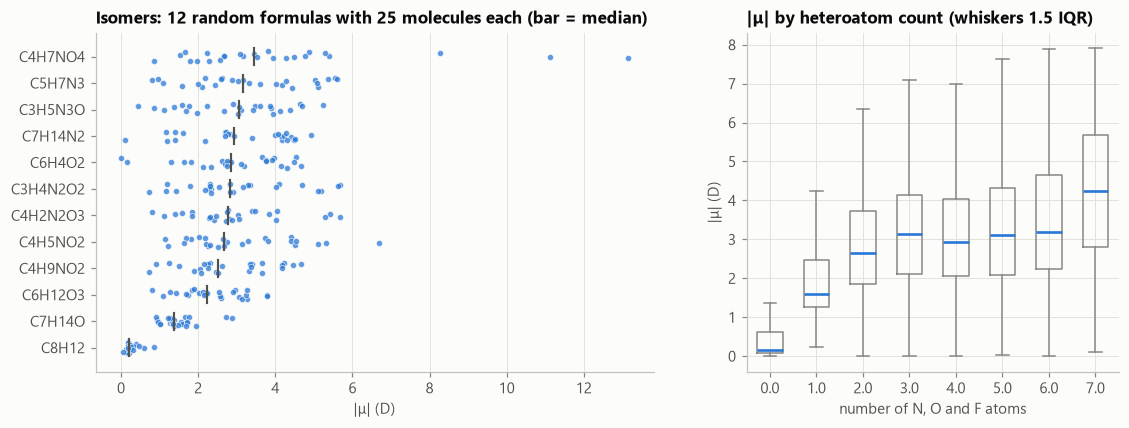

In [15]:
from qm9dipole.analysis import formula_variance

fv = formula_variance(y, formula, min_count=5)
print(f"{fv['n_formulas']} formulas with ≥ 5 molecules ({fv['n_molecules']:,} molecules):")
print(f"  variance explained by the formula: η² = {fv['eta2']:.2f}, ω² = {fv['omega2']:.2f}")
print(f"  isomers of one formula: within-formula std {fv['within_std']:.2f} D (total {fv['total_std']:.2f} D); "
      f"mean |μ − formula mean| {fv['within_mae']:.2f} D, a floor for composition-only models")

n_het = summaries["n_N"] + summaries["n_O"] + summaries["n_F"]
counts = formula.value_counts()
rng = np.random.default_rng(0)
capped = counts[counts == counts.max()].sort_index().index
shown = rng.choice(capped, size=12, replace=False)
order_f = y.groupby(formula).median().loc[shown].sort_values().index

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1.5, 1]})
for i, f in enumerate(order_f):
    v = y[formula == f]
    ax0.scatter(v, i + rng.uniform(-0.2, 0.2, len(v)), s=16, color=SERIES[0], alpha=0.75, edgecolors=SURFACE,
                linewidths=0.5)
    ax0.plot([v.median()] * 2, [i - 0.32, i + 0.32], color=INK_SECONDARY, linewidth=1.4)
ax0.set(yticks=range(len(order_f)), yticklabels=order_f, xlabel="|μ| (D)",
        title=f"Isomers: {len(order_f)} random formulas with {counts.max()} molecules each (bar = median)")
ax0.grid(axis="y", visible=False)
groups = sorted(n_het.unique())
style = dict(color=MUTED, linewidth=1)
ax1.boxplot([y[n_het == h] for h in groups], positions=groups, widths=0.55, showfliers=False,
            medianprops=dict(color=SERIES[0], linewidth=1.75), boxprops=style, whiskerprops=style, capprops=style)
ax1.set(xlabel="number of N, O and F atoms", ylabel="|μ| (D)", title="|μ| by heteroatom count (whiskers 1.5 IQR)")
fig.savefig(FIG_DIR / "explore01_formula.png")
plt.show()

## 11. Outliers

Two screens per field: |z| > 3 (assumes a roughly normal bulk) and Tukey's fences (beyond 1.5 IQR from the
quartiles; assumes nothing about shape). In a valid computed dataset an outlier is not an error: the high-|μ| tail
is zwitterions, which separate a full charge across the molecule. M1 decided to **keep** them (DECISIONS.md). They
weigh heavily on RMSE, which is why MAE is the primary metric.

In [16]:
z = (scalars - scalars.mean()) / scalars.std()
q1, q3 = scalars.quantile(0.25), scalars.quantile(0.75)
iqr = q3 - q1
tukey = (scalars < q1 - 1.5 * iqr) | (scalars > q3 + 1.5 * iqr)
outliers = pd.DataFrame({"|z| > 3": (z.abs() > 3).sum(), "outside Tukey fences": tukey.sum(),
                         "share outside fences": tukey.mean()})
display(outliers.sort_values("|z| > 3", ascending=False).style.format({"share outside fences": "{:.1%}"}))
zw = charge["max_abs_charge"]
print(f"|μ| ≥ 9 D: {(y >= 9).sum()} molecules, median max |q| {zw[y >= 9].median():.2f} e "
      f"vs {zw[y < 9].median():.2f} e for the rest: separated charges (zwitterion-like)")

,|z| > 3,outside Tukey fences,share outside fences
n_F,357,1031,14.5%
freq_min,92,250,3.5%
n_N,86,86,1.2%
r2,75,254,3.6%
mu,49,85,1.2%
homo,47,192,2.7%
alpha,42,71,1.0%
n_heavy,38,600,8.4%
centroid_offset,37,41,0.6%
freq_max,34,34,0.5%


|μ| ≥ 9 D: 32 molecules, median max |q| 0.53 e vs 0.45 e for the rest: separated charges (zwitterion-like)


## 12. Findings and recommendations

The table below is what the later notebooks act on. Each row names a finding and the step that handles it. It is
saved to `results/explore01_recommendations.csv`, and notebook 02 prints it before acting on it.

In [17]:
skewed = [c for c in stats.index if abs(stats.loc[c, "skew"]) > CFG["standardization"]["skew_threshold"]]
recommendations = pd.DataFrame([
    ("roles", "q, the 11 electronic/thermal properties, freqs", "DFT outputs from the same calculation as |μ|",
     "exploration-only block; never in a headline feature set", "02"),
    ("A, B, C", "rotational constants", "exactly 505.379 GHz·amu·Å² / I(Z, R), so legal; A = 0 marks a linear molecule (∞); heavy tail",
     "replace with inertia moments computed from Z and R (finite, same information)", "02"),
    ("freqs", f"{int(doubled.sum())} doubled lists", "raw-file artifact: the list is printed twice",
     "keep the first copy; summarize the spectrum", "02"),
    ("duplicates", f"{len(geo)} molecules in {geo.nunique()} groups", "same geometry and |μ|; no S_(s,N) holds both twins; InChI merges tautomers",
     "keep one per group in pool-wide analyses; identify by geometry, not InChI", "02"),
    ("redundancy", f"{(near.abs() >= threshold).sum()} pairs with |ρ| ≥ {threshold}", "e.g. U0/U/H/G, size counts",
     f"drop the later of each pair (cleaning.redundancy_spearman = {threshold})", "02"),
    ("bond lengths", "C≡C, C≡N, C=O, N=O peaks separated by empty valleys", "bond order is readable from geometry",
     "count multiple bonds by length (polar groups)", "02"),
    ("long tails", f"{len(skewed)} fields with |skew| > {CFG['standardization']['skew_threshold']}",
     ", ".join(skewed[:8]) + ("…" if len(skewed) > 8 else ""),
     "compare log / power / quantile scaling against z-scores by CV", "03"),
    ("target", f"skewness {y.skew():.2f}; √|μ| {np.sqrt(y).skew():.2f}", "right tail of zwitterions; spike near 0",
     "compare raw, √ and log(1+·) targets by CV (predictions inverted to debye)", "03"),
    ("composition", f"ω² = {fv['omega2']:.2f}", "the formula explains a minority of the variance",
     "geometry-aware features are essential; composition-only is a baseline", "04"),
    ("outliers", f"{(y >= 9).sum()} molecules ≥ 9 D", "zwitterions: valid computed values",
     "keep; report MAE (primary) and RMSE, and RMSE without the tail", "05"),
], columns=["topic", "evidence", "finding", "action", "notebook"])
save_result(recommendations, "explore01_recommendations", label="exploratory EDA on the training pool P")
display(recommendations.style.hide(axis="index"))

topic,evidence,finding,action,notebook
roles,"q, the 11 electronic/thermal properties, freqs",DFT outputs from the same calculation as |μ|,exploration-only block; never in a headline feature set,02
"A, B, C",rotational constants,"exactly 505.379 GHz·amu·Å² / I(Z, R), so legal; A = 0 marks a linear molecule (∞); heavy tail","replace with inertia moments computed from Z and R (finite, same information)",02
freqs,25 doubled lists,raw-file artifact: the list is printed twice,keep the first copy; summarize the spectrum,02
duplicates,24 molecules in 12 groups,"same geometry and |μ|; no S_(s,N) holds both twins; InChI merges tautomers","keep one per group in pool-wide analyses; identify by geometry, not InChI",02
redundancy,6 pairs with |ρ| ≥ 0.99,"e.g. U0/U/H/G, size counts",drop the later of each pair (cleaning.redundancy_spearman = 0.99),02
bond lengths,"C≡C, C≡N, C=O, N=O peaks separated by empty valleys",bond order is readable from geometry,count multiple bonds by length (polar groups),02
long tails,8 fields with |skew| > 1.0,"A, B, C, mu, n_heavy, n_F, freq_min, freq_max",compare log / power / quantile scaling against z-scores by CV,03
target,skewness 1.73; √|μ| -0.26,right tail of zwitterions; spike near 0,"compare raw, √ and log(1+·) targets by CV (predictions inverted to debye)",03
composition,ω² = 0.31,the formula explains a minority of the variance,geometry-aware features are essential; composition-only is a baseline,04
outliers,32 molecules ≥ 9 D,zwitterions: valid computed values,"keep; report MAE (primary) and RMSE, and RMSE without the tail",05


### Summary

1. **The data is clean.** All 7,131 pool molecules pass every consistency rule: neutral charges, gap = lumo − homo
   to the file's rounding, H − U = RT, U0 < U and G < H, A ≥ B ≥ C, no imaginary frequencies, a connected bond graph,
   and no missing values. The only artifact is **25 frequency lists printed twice** in the raw files (identical
   halves).
2. **Roles.** The rotational constants A, B, C are exact functions of Z and R (relative deviation ≤ 1.2 × 10⁻⁵), so
   they are headline-legal. Thirteen fields (charges, the 11 electronic and thermal properties, frequencies) are DFT
   outputs and stay exploration-only.
3. **Duplicates.** 12 pairs of true duplicates (identical geometry and |μ|), including two of the six largest |μ|.
   InChI would also have merged 159 groups of **tautomers**, different molecules whose |μ| differ by up to 6.3 D, so
   duplicates must be found by geometry. No training set holds both twins, and a unit test now guards this.
4. **The target** is right-skewed (skewness 1.73), with 26 exact zeros and 32 zwitterions at ≥ 9 D (up to 29.6 D).
   √|μ| is nearly symmetric (−0.26). Always predicting the median scores MAE 1.34 D: the floor to beat.
5. **What carries information.** By far the strongest single field is the Mulliken point-charge dipole (r = 0.93),
   but it is a DFT output. Among legal fields, the composition counts help most, and only weakly (n_H, n_N), and
   the formula explains under a third of the variance (ω² = 0.31). Isomers differ by 1.46 D (std): **geometry is
   essential.**
6. **Useless fields.** `centroid_offset` (MI 0.002): QM9 stores molecules in arbitrary frames (only 6.9% are
   principal-axis aligned), so raw positions carry no chemistry, which also supports the invariant descriptors.
   The rotational constants (MI ≤ 0.03) and n_heavy (0.01) carry almost nothing on their own.
7. **Redundancy.** U0, U, H and G are identical in rank (ρ = 1.0000). zpve tracks n_H (ρ = 0.988) because X–H
   stretches dominate zero-point energy, and r2 tracks the rotational constants (−0.95): both measure size.
8. **Shapes.** Eight fields have |skewness| > 1. A, B and C are extreme (skewness 50–73; A reaches 619,868 GHz for
   near-linear molecules), which their reciprocals, the moments of inertia, avoid.
9. **Bond lengths encode bond order.** C≡C, C≡N, C=O and N=O peaks are separated from single bonds by empty valleys.
   C–C double vs single and N–N are not.

**Carried forward:** notebook 02 implements every row of the recommendations table above. Notebook 03 tests the
transforms that the shapes in points 4 and 8 call for.